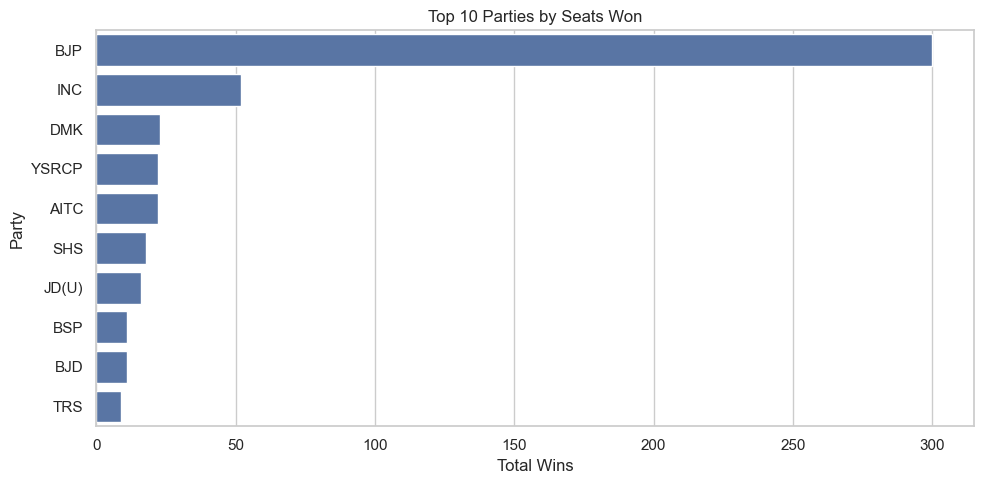

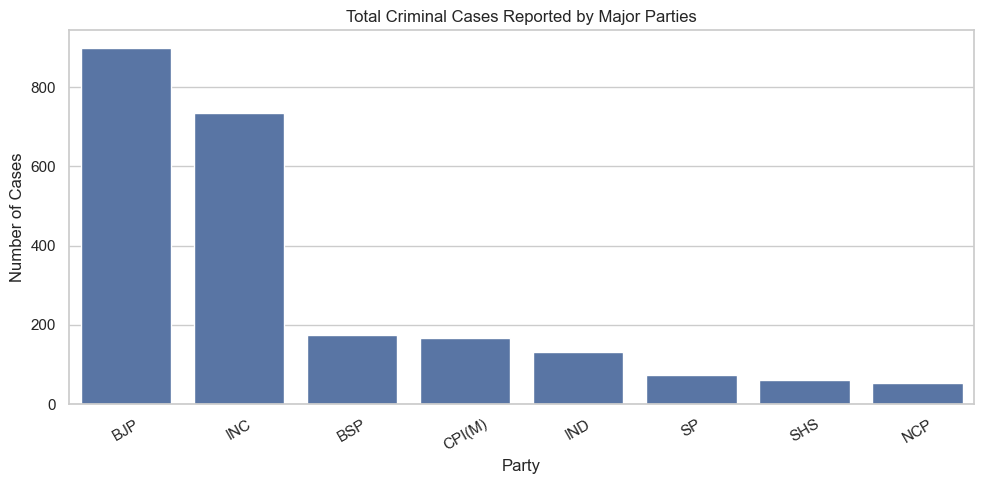

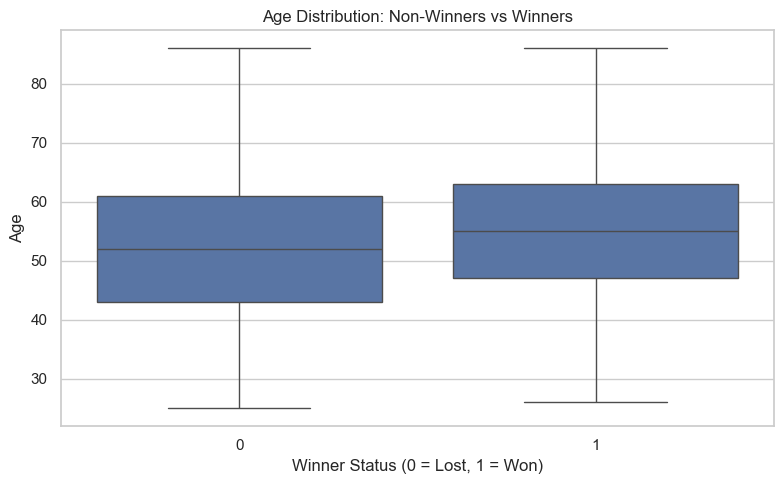

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import io

# 1. Clean the CSV file content from broken line breaks
with open("election data.csv", "r", encoding="utf-8") as f:
    raw_content = f.read()

# Fix multi-line entries in quotes and header newlines
clean_content = raw_content.replace('\n', ' ')
clean_content = clean_content.replace('  ', ' ')

# Reload cleanly into dataframe
df = pd.read_csv("election data.csv")
df.columns = df.columns.str.replace('\n', ' ').str.replace('"', '').str.strip()

# Dynamic column search helper
def get_col(keyword):
    cols = [c for c in df.columns if keyword.lower() in c.lower()]
    return cols[0] if cols else keyword

party_col = get_col('party')
winner_col = get_col('winner')
age_col = get_col('age')
criminal_col = get_col('criminal')
assets_col = get_col('assets')

# Helper function to clean money values
def parse_currency(val):
    if pd.isna(val):
        return 0
    val_str = str(val).replace(',', '').strip()
    if 'Crore' in val_str:
        num = re.findall(r"[-+]?\d*\.\d+|\d+", val_str)
        return float(num[0]) * 10000000 if num else 0
    elif 'Lac' in val_str:
        num = re.findall(r"[-+]?\d*\.\d+|\d+", val_str)
        return float(num[0]) * 100000 if num else 0
    else:
        num = re.findall(r"\d+", val_str)
        return float("".join(num)) if num else 0

# Data conversions
df[criminal_col] = pd.to_numeric(df[criminal_col], errors='coerce').fillna(0)
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
df[winner_col] = pd.to_numeric(df[winner_col], errors='coerce')
if assets_col in df.columns:
    df['ASSETS_CLEAN'] = df[assets_col].apply(parse_currency)

sns.set_theme(style="whitegrid")

# Graph 1: Top Parties by Wins
plt.figure(figsize=(10, 5))
top_winners = df[df[winner_col] == 1][party_col].value_counts().head(10)
sns.barplot(x=top_winners.values, y=top_winners.index)
plt.title("Top 10 Parties by Seats Won")
plt.xlabel("Total Wins")
plt.ylabel("Party")
plt.tight_layout()
plt.show()

# Graph 2: Criminal Cases by Party
plt.figure(figsize=(10, 5))
party_cases = df.groupby(party_col)[criminal_col].sum().sort_values(ascending=False).head(8)
sns.barplot(x=party_cases.index, y=party_cases.values)
plt.title("Total Criminal Cases Reported by Major Parties")
plt.xlabel("Party")
plt.ylabel("Number of Cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Graph 3: Age Distribution
if age_col in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=winner_col, y=age_col)
    plt.title("Age Distribution: Non-Winners vs Winners")
    plt.xlabel("Winner Status (0 = Lost, 1 = Won)")
    plt.ylabel("Age")
    plt.tight_layout()
    plt.show()
    
